In [1]:

import numpy as np
# from shapely.geometry import Polygon
from PIL import Image
import matplotlib.pyplot as plt

import json
from typing import List, Dict, Union
import pyproj
from pyproj import Transformer
import math

# from sentinelhub import SHConfig, BBox, CRS, DataCollection, MimeType, SentinelHubRequest
from typing import Tuple, Optional

import ee

In [27]:
# --- AUTHENTICATE ONCE (outside the function) ---
# Run this ONCE in a Python shell or at the start of your script:
# ee.Authenticate()
def download_google_earth_rgb(bbox, scale, output_file="google_earth_rgb.png"):

    # Initialize Earth Engine
    ee.Initialize()

    # Define your region of interest
    region = ee.Geometry.Rectangle(bbox)

    # Get a high-resolution image (e.g., WorldView-3)
    image = ee.ImageCollection("COPERNICUS/S2_SR").filterBounds(region).first()
    
    if not image:
        raise ValueError("No images found for the given bounding box.")
    rgb_image = image.select(["B4", "B3", "B2"])
    # Get the RGB visualization URL
    url = rgb_image.getThumbURL({
        "region": region,
        "scale": scale,
        "min": 0,
        "max": 3000,  # Adjust for Sentinel-2 reflectance values
    })

    # Download the image
    import requests
    from PIL import Image
    from io import BytesIO
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    img.save(output_file)
    print(f"✅ Image saved to {output_file}")
    return img




✅ Image saved to google_earth_rgb.png


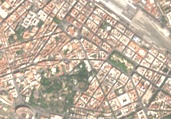

In [25]:
# Example usage:
bbox = [12.49, 41.89, 12.51, 41.90]  # Rome, Italy (as [min_lon, min_lat, max_lon, max_lat])
download_google_earth_rgb(bbox=bbox, scale=10)

In [26]:
print('ciao')

ciao
